# 은행 마케팅 캠페인 분석

신규 고객(41,860명)을 대상으로 정기예금 가입률에 영향을 미치는 요인을 분석하고 타겟 마케팅 전략을 도출함

- 전체 평균 가입률: 15.5%
- 분석 변수: 연령대, 직업, 월별, 통화시간, 연락횟수

> **분석 방향**: 단순 현황 파악에 그치지 않고, 각 변수별로 가설을 세우고 통계적으로 검증하여 실행 가능한 타겟 마케팅 전략을 도출함

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 폰트 설정
font_path = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'
font = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = font.get_name()
 

new  = pd.read_csv('new_customers_cleaned.csv')
prev = pd.read_csv('prev_customers_cleaned.csv')

print(new.shape)
print(new.head())

age_order = ['29세이하', '30대', '40대', '50대', '60세이상']

(41860, 22)
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day  ... campaign  pdays  previous  poutcome  deposit deposit_yn age_grp  \
0    5  ...        1     -1         0   unknown      yes          1     50대   
1    5  ...        1     -1         0   unknown      yes          1     50대   
2    5  ...        1     -1         0   unknown      yes          1     40대   
3    5  ...        1     -1         0   unknown      yes          1     50대   
4    5  ...        2     -1         0   unknown      yes          1     50대   

   bal_grp month_n month_l

## 연령대별 가입률


**가설**: 연령대에 따라 정기예금 가입률이 다를 것이다.
- 고연령층일수록 자산 여유가 있어 가입률이 높을 것으로 예상

In [3]:
age_rate = (
    new.groupby('age_grp')['deposit_yn']
    .mean()
    .reindex(age_order) * 100
)
print(f"\n연령대별 가입률(%):")
print(age_rate.round(1))


연령대별 가입률(%):
age_grp
29세이하    23.3
30대      14.0
40대      12.2
50대      12.5
60세이상    40.5
Name: deposit_yn, dtype: float64


## 연령대 × 주택대출 교차 분석

**가설**: 주택대출이 없는 고객이 재정 부담이 낮아 가입률이 높을 것이다.
- 주택대출 유무를 연령대와 교차 분석하여 핵심 타겟 조합을 도출

In [4]:
age_housing = (
    new.groupby(['age_grp', 'housing'])['deposit_yn']
    .mean()
    .unstack()
    .reindex(age_order) * 100
)
print(f"\n연령대 × 주택대출 가입률(%):")
print(age_housing.round(1))


연령대 × 주택대출 가입률(%):
housing    no   yes
age_grp            
29세이하    35.4  13.9
30대      18.3  11.3
40대      15.6   9.5
50대      15.3   8.6
60세이상    42.3  30.3


## 직업별 가입률

**가설**: 재정적으로 안정적인 직군일수록 예금 가입률이 높을 것이다.
- student, retired 등 대출 부담이 낮은 직군과 blue-collar 등 소득 불안정 직군 비교

In [5]:
job_rate = (
    new.groupby('job')['deposit_yn']
    .mean()
    .sort_values(ascending=False) * 100
)
print(f"\n직업별 가입률(%):")
print(job_rate.round(1))


직업별 가입률(%):
job
student          35.4
retired          27.6
unemployed       18.2
management       17.0
self-employed    15.8
admin.           15.5
technician       15.3
unknown          12.8
entrepreneur     12.6
services         12.5
housemaid        11.6
blue-collar      11.2
Name: deposit_yn, dtype: float64


In [6]:
avg = new['deposit_yn'].mean() * 100

## 핵심 타겟 조합 가입률 계산 

앞선 분석을 바탕으로 가입 가능성이 높은 타겟 조합의 실제 가입률을 산출함

In [7]:
targets = {
    '60세이상 (주택대출X)': new[(new['age_grp']=='60세이상') & (new['housing']=='no')]['deposit_yn'].mean(),
    '29세이하 (개인대출X)': new[(new['age_grp']=='29세이하') & (new['loan']=='no')]['deposit_yn'].mean(),
    '은퇴자 (대출X)': new[(new['job']=='retired')    & (new['loan']=='no')]['deposit_yn'].mean(),
    '학생': new[new['job']=='student']['deposit_yn'].mean(),
}
print(f"핵심 타겟층 가입률:")
for k, v in targets.items():
    print(f"{k}: {v*100:.1f}%")

핵심 타겟층 가입률:
60세이상 (주택대출X): 42.3%
29세이하 (개인대출X): 25.0%
은퇴자 (대출X): 30.6%
학생: 35.4%


## 통화 시간별 성공률 계산

**가설**: 통화 시간이 길수록 가입률이 높을 것이다.
- 단, 인과관계 방향 주의: 통화가 길어서 설득된 것인지, 원래 관심 있어서 오래 통화한 것인지 구분 필요

In [8]:
new['dur_min'] = new['duration'] // 60
dur_rate = new.groupby('dur_min')['deposit_yn'].mean().reset_index()
 
print(f"11분 이상 성공률: {new[new['duration']>=660]['deposit_yn'].mean()*100:.1f}%")
print(f"11분 미만 성공률: {new[new['duration']<660]['deposit_yn'].mean()*100:.1f}%")

11분 이상 성공률: 63.6%
11분 미만 성공률: 10.7%


In [9]:
camp_rate = new.groupby('campaign')['deposit_yn'].mean().reset_index()
print(f"연락 횟수별 성공률:")
print(camp_rate[camp_rate['campaign'] <= 6].round(3))

연락 횟수별 성공률:
   campaign  deposit_yn
0         1       0.181
1         2       0.144
2         3       0.142
3         4       0.131
4         5       0.113
5         6       0.105


## 월별 마케팅 성공률 계산

**가설**: 계절(월)에 따라 마케팅 성공률이 다를 것이다.
- 연초·연말은 자산 관리 관심도가 높아 성공률이 높을 것으로 예상

In [10]:
month_rate = (
    new.groupby('month_n')['deposit_yn']
    .mean()
    .reset_index()
    .sort_values('month_n')
)
month_rate['month'] = month_rate['month_n'].map(
    {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
     7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
)
 
summer_r = new[new['month_n'].isin([5,6,7,8])]['deposit_yn'].mean() * 100
other_r  = new[~new['month_n'].isin([5,6,7,8])]['deposit_yn'].mean() * 100
print(f"5~8월 가입률: {summer_r:.1f}%  |  9~4월 가입률: {other_r:.1f}%")

5~8월 가입률: 11.7%  |  9~4월 가입률: 26.5%


## 연령대 × 주택대출 시각화

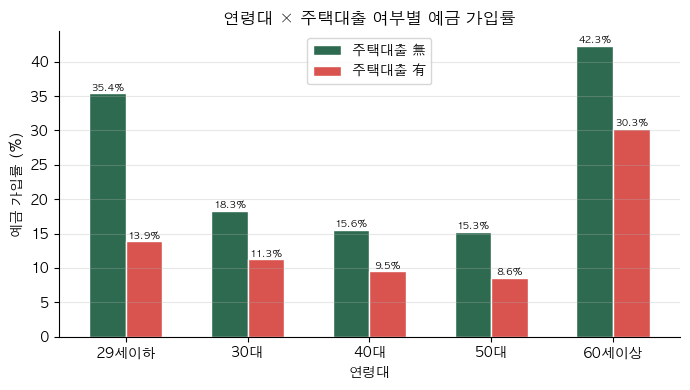

In [12]:
age_housing.columns = ['주택대출 無', '주택대출 有']
 
fig, ax = plt.subplots(figsize=(7, 4))
age_housing.plot(kind='bar', ax=ax, color=['#2D6A4F', '#D9534F'],
                 width=0.6, edgecolor='white')
ax.set_xlabel('연령대')
ax.set_ylabel('예금 가입률 (%)')
ax.set_title('연령대 × 주택대출 여부별 예금 가입률', fontweight='bold')
ax.tick_params(axis='x', rotation=0)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
for bar in ax.patches:
    if bar.get_height() > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{bar.get_height():.1f}%', ha='center', fontsize=7)
plt.tight_layout()
plt.show()

모든 연령대에서 주택대출 없는 고객의 가입률이 높게 나타남.  
특히 29세 이하의 경우 35.4% vs 13.9%로 대출 유무에 따른 차이가 가장 큼.  
60세 이상은 대출이 있어도 30.3%로 다른 연령대 대비 높은 수준.  
→ 연령이 높을수록 예금 선호도 자체가 높아지는 경향.  
40~50대는 대출 유무와 관계없이 전반적으로 가입률이 낮음.  
→ 해당 연령대는 마케팅 우선순위에서 후순위로 설정 필요.

## 직업별 가입률 시각화

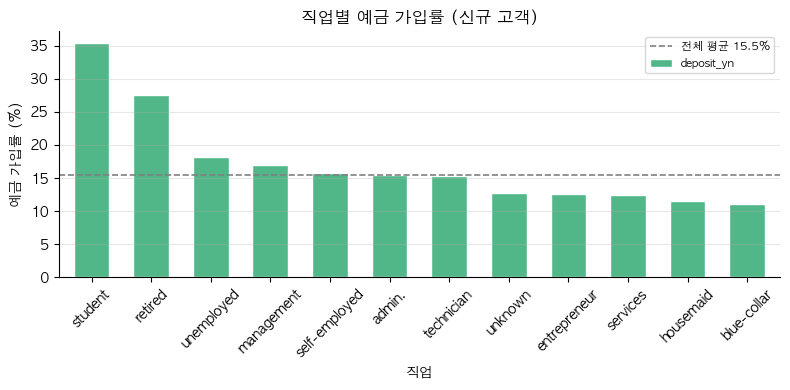

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
job_rate.plot(kind='bar', ax=ax, color='#52B788', edgecolor='white', width=0.6)
ax.axhline(avg, ls='--', color='gray', lw=1.2, label=f'전체 평균 {avg:.1f}%')
ax.set_xlabel('직업')
ax.set_ylabel('예금 가입률 (%)')
ax.set_title('직업별 예금 가입률 (신규 고객)', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

student, retired가 가입률 상위권으로 재무 부담이 낮은 직군에서 높은 가입률.  
blue-collar, housemaid, services는 하위권으로 소득 안정성이 낮은 직군일수록 가입률이 낮은 패턴.  
unknown 직업군 존재 → 데이터 수집 단계에서 직업 정보 누락으로 판단.  
→ 재무적으로 안정적이거나 여유 있는 직군을 우선 타겟으로 설정 필요.

## 월별 마케팅 성공률 시각화

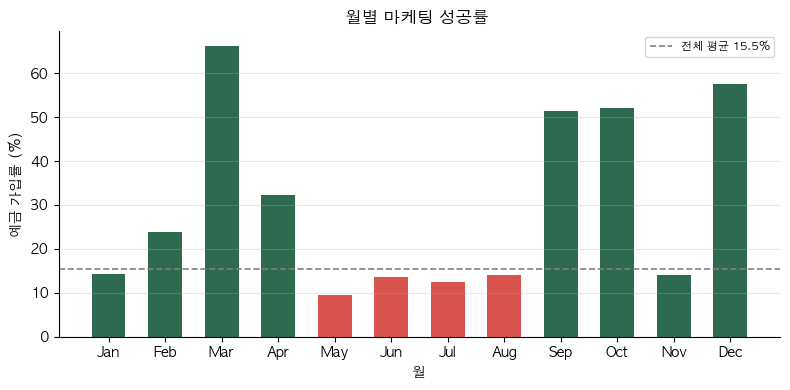

In [14]:
clrs_m = ['#D9534F' if m in [5,6,7,8] else '#2D6A4F' for m in month_rate['month_n']]
 
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(month_rate['month'], month_rate['deposit_yn']*100, color=clrs_m, width=0.6)
ax.axhline(avg, ls='--', color='gray', lw=1.2, label=f'전체 평균 {avg:.1f}%')
ax.set_xlabel('월')
ax.set_ylabel('예금 가입률 (%)')
ax.set_title('월별 마케팅 성공률 ', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


3월 성공률 65%로 압도적으로 높으며, 9-12월도 50% 이상 유지.  
반면 5-8월은 10% 초반대로 급격히 낮아짐.  
5-8월에 데이터가 집중되어 있어 표본 수 차이가 영향을 줬을 가능성 있음.  
→ 다만 여름 시즌 성공률이 낮다는 경향은 전반적으로 명확하게 확인됨.  
→ 3월, 9-12월 집중 운영 / 5-8월 캠페인 최소화 전략 권장.

## 통화 시간별 성공률 시각화

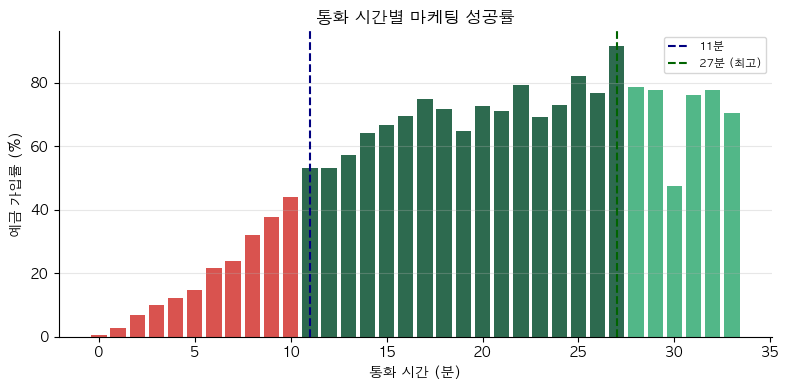

In [15]:
dr     = dur_rate[dur_rate['dur_min'] <= 33]
clrs_d = ['#D9534F' if m < 11 else '#2D6A4F' if m <= 27 else '#52B788'
          for m in dr['dur_min']]
 
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dr['dur_min'], dr['deposit_yn']*100, color=clrs_d, width=0.8)
ax.axvline(11, ls='--', color='navy', lw=1.5, label='11분')
ax.axvline(27, ls='--', color='darkgreen', lw=1.5, label='27분 (최고)')
ax.set_xlabel('통화 시간 (분)')
ax.set_ylabel('예금 가입률 (%)')
ax.set_title('통화 시간별 마케팅 성공률', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

11분을 기점으로 성공률이 역전됨.  
11분 미만 10.7% vs 11분 이상 63.6%로 차이가 매우 큼.  
27분 구간에서 성공률이 가장 높게 나타남.  
2000초 이상 이상치 제거로 33분까지만 분석.  
→ 다만 통화 시간과 가입률의 인과관계 방향은 불명확.  
    (통화가 길어서 설득된 것인지, 원래 관심 있는 고객이 오래 통화한 것인지 판단 어려움)  
    → 목표 통화 시간 11~27분으로 설정 권장.

## 연락횟수별 성공률 시각화

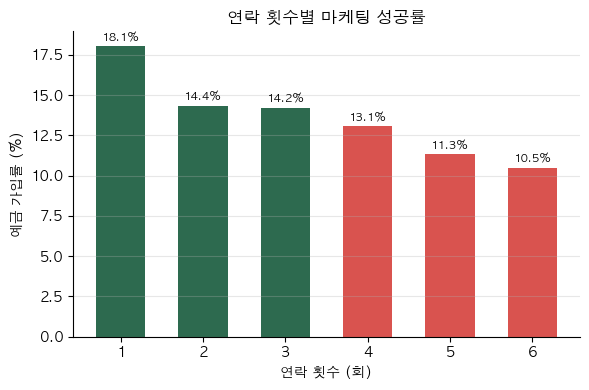

In [16]:
cp     = camp_rate[camp_rate['campaign'] <= 6]
clrs_c = ['#2D6A4F' if n <= 3 else '#D9534F' for n in cp['campaign']]
 
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(cp['campaign'], cp['deposit_yn']*100, color=clrs_c, width=0.6)
for _, row in cp.iterrows():
    ax.text(row['campaign'], row['deposit_yn']*100+0.3,
            f"{row['deposit_yn']*100:.1f}%", ha='center', fontsize=8, fontweight='bold')
ax.set_xlabel('연락 횟수 (회)') 
ax.set_ylabel('예금 가입률 (%)')
ax.set_title('연락 횟수별 마케팅 성공률', fontweight='bold')
ax.set_xticks(cp['campaign'])
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

1회 연락 성공률 18.1%에서 2회부터 급격히 하락, 6회에는 10.5%까지 감소.  
연락 횟수가 늘수록 성공률이 단조감소하는 패턴 확인.  
1회가 가장 효율적이며 3회까지는 유사한 수준을 유지하나 이후 역효과 발생.  
→ 과도한 재연락이 고객 거부감을 높이는 것으로 판단.  
→ 최대 연락 횟수 3회 이내로 제한하는 운영 기준 설정 필요.

## 핵심 타겟층 가입률 비교 시각화

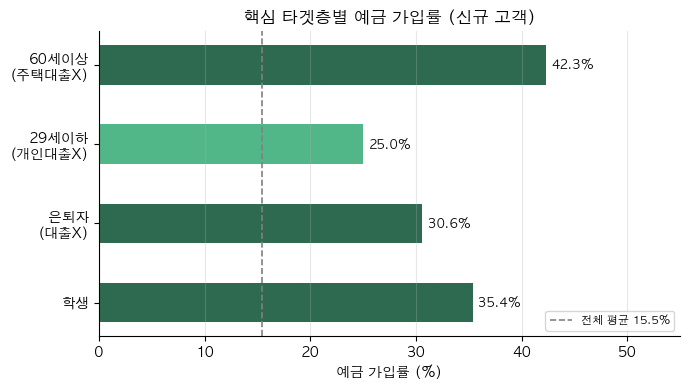

In [11]:
labels = ['60세이상\n(주택대출X)', '29세이하\n(개인대출X)', '은퇴자\n(대출X)', '학생']
rates  = [v*100 for v in targets.values()]
clrs   = ['#2D6A4F' if r >= 30 else '#52B788' for r in rates]
 
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(labels, rates, color=clrs, height=0.5)
ax.axvline(avg, ls='--', color='gray', lw=1.2, label=f'전체 평균 {avg:.1f}%')
for bar, r in zip(bars, rates):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
            f'{r:.1f}%', va='center', fontsize=9, fontweight='bold')
ax.set_xlim(0, 55)
ax.set_xlabel('예금 가입률 (%)')
ax.set_title('핵심 타겟층별 예금 가입률 (신규 고객)', fontweight='bold')
ax.legend(fontsize=8)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 핵심 타겟층 가입률

60세 이상 (주택대출X) 가입률 42.3%로 가장 높음.  
전체 평균 15.5% 대비 약 2.7배 수준.  
학생(35.4%)은 대출 부담이 없어 가입 저항이 낮은 것으로 판단.   
29세 이하 (개인대출X)는 25.0%로 상대적으로 낮음.  
→ 젊은 층은 예금보다 다른 금융상품 선호 가능성 있음.

## 핵심 인사이트

- 60세 이상(주택대출X) 가입률 42.3%로 가장 높음
- 5~8월 성공률 10% 초반대 → 비수기
- 통화 11분 이상 성공률 63.6%로 역전
- 연락 횟수 3회 이내가 가장 효율적